In [1]:
import numpy as np
import matplotlib.pyplot as plt
import OptimalBattery.util as ut
import os
import PcmPy as pcm
import seaborn as sns
import pandas as pd
import OptimalBattery.evaluate as ev
import Functional_Fusion.atlas_map as am
from Functional_Fusion.dataset import DataSetMDTB
from IndividualParcellation.global_config import *
import nilearn.plotting as plotting
import nitools as nt
import nibabel as nb
import OptimalBattery.estimate as es
import OptimalBattery.construct as ct
import OptimalBattery.plot as plot



Default device set to: cuda


In [2]:
# define atlas and dirs
space = 'fs32k'
atlas,_= am.get_atlas(atlas_str=space)
base_dir = 'Y:/data/'
if not os.path.exists(base_dir):
    base_dir = '/cifs/diedrichsen/data/'

func_fus_dir = os.path.join(base_dir, 'FunctionalFusion')
cerebellum_dir = os.path.join(base_dir, 'Cerebellum')


# roi (prefrontal cortex)
atlas_dir = f'{func_fus_dir}/Atlases/tpl-fs32k'
model_name_L = f'{atlas_dir}/glasser.L.label.gii'
model_name_R = f'{atlas_dir}/glasser.R.label.gii'
glasser_atlas = atlas.read_data([model_name_L,model_name_R])

In [6]:
# Load surface files for left and right hemispheres
surfs = [f"{func_fus_dir}/Atlases/tpl-fs32k/tpl-fs32k_hemi-{h}_inflated.surf.gii" for h in ['L', 'R']]
def plot_cortex(data, threshold=0.0, cmap='binary', figsize=(12, 6),view='lateral'):

    # Convert data to CIFTI format
    cifti = atlas.data_to_cifti(data)
    
    # Extract data for the cortical surfaces
    all_img = nt.surf_from_cifti(cifti)
    
    # Create the plot
    fig, axes = plt.subplots(1, 2, subplot_kw={'projection': '3d'}, figsize=figsize)
    for h, hemi in enumerate(['left', 'right']):
        plotting.plot_surf_stat_map(
            surfs[h], all_img[h], hemi=hemi,
            colorbar=False,
            cmap=cmap,
            axes=axes[h],
            threshold=threshold,
            title=f'figure {h+1}', view=view
        )
    
    return fig

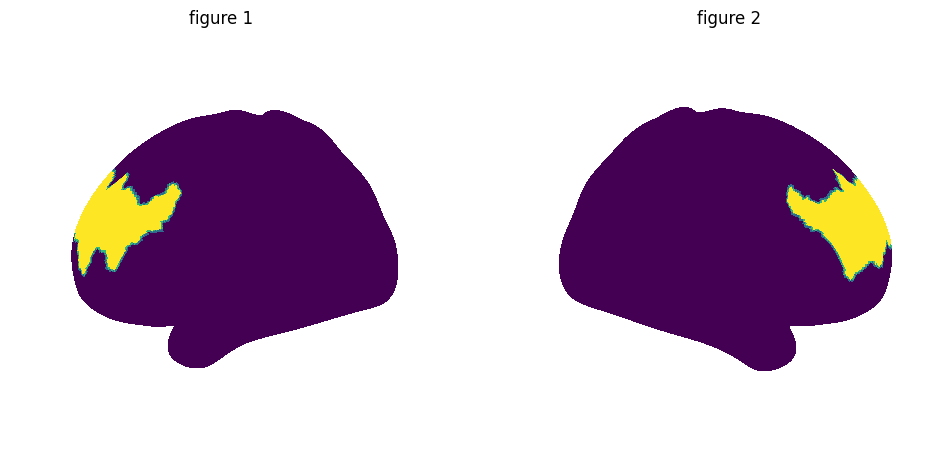

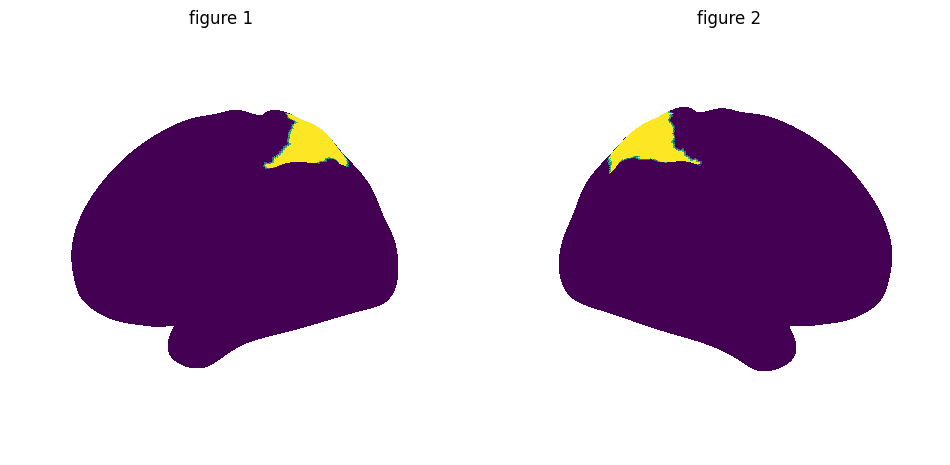

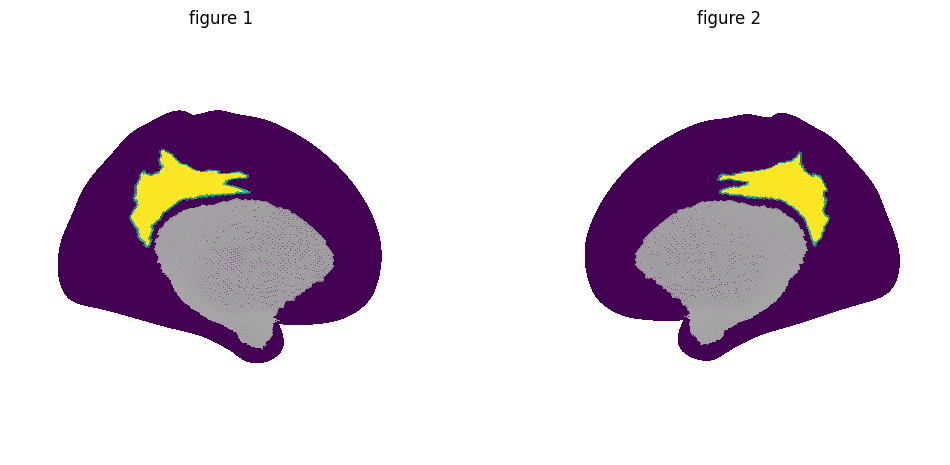

In [7]:
rois = {
    'Dorsolateral_PFC': ['9-46d', '46', '9a', 'a9-46v', 'p9-46v', '9p', 'IFJa', 'IFJp', 'IFSp', 'IFSa'],
    'Parietal_Multisensory': ['LIPv', 'LIPd', 'VIP', 'MIP', 'AIP', '7PC', '7AL', '7Am'],
    'Posterior_Cingulate': ['d23ab', 'v23ab', '23c', '23d', '31pv', '31pd', '31a']
}

for roi, parcels in rois.items():
    gifti_data = nb.load(model_name_L)
    parcel_names = [label.label for label in gifti_data.labeltable.labels]
    parcel_names = [name[len("L_"):] if name.startswith("L_") else name for name in parcel_names]
    parcel_names = [name[:-len("_ROI")] if name.endswith("_ROI") else name for name in parcel_names]

    # Get the indices of the PFC parcels
    ROI_cortex = []
    for name in parcels:
        ROI_cortex.append(parcel_names.index(name))

    ROI_mask = np.isin(glasser_atlas, ROI_cortex).astype(int)
    # add axis
    ROI_mask = ROI_mask[ np.newaxis,:]
    if roi == 'Posterior_Cingulate':
        fig = plot_cortex(ROI_mask, cmap='viridis', figsize=(12, 6),view='medial')
    else:
        fig = plot_cortex(ROI_mask, cmap='viridis', figsize=(12, 6),view='lateral')
    